In [1]:
!pip install transformers torchaudio "onnxruntime==1.20.1" "onnx==1.20.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.4 MB/s eta 0:00:00


In [2]:
from huggingface_hub import login

hf_token = "your_hf_token"

login(token=hf_token)
print("Successfully logged into Hugging Face Hub!")

Successfully logged into Hugging Face Hub!


**Loading the model**

In [3]:
from transformers import AutoModel
import torch
import torchaudio

# 1. Load the model
print("Loading the model... (This will take a few minutes on first run)")
model = AutoModel.from_pretrained("ai4bharat/indic-conformer-600m-multilingual", trust_remote_code=True)

# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(f"Model loaded on {device}")



Loading the model... (This will take a few minutes on first run)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

model_onnx.py:   0%|          | 0.00/9.64k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indic-conformer-600m-multilingual:
- model_onnx.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Please check FRAME_DURATION_MS. The timestamps can be inaccurate
Please check FRAME_DURATION_MS. The timestamps can be inaccurate


Fetching 404 files:   0%|          | 0/404 [00:00<?, ?it/s]

Please check FRAME_DURATION_MS. The timestamps can be inaccurate


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:115: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Model loaded on cuda


**Importing dataset from huggingface**

In [4]:
!pip install -q datasets huggingface_hub

In [5]:
from datasets import load_dataset

In [6]:
marathi_valid = load_dataset(
    "ai4bharat/IndicVoices",
    "marathi",
    split="valid",        # the split name inside the config; usually “train” for the data split
    streaming=True       # streams rows on‑demand
)

README.md:   0%|          | 0.00/38.8k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/88 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/75 [00:00<?, ?it/s]

In [7]:
row_count = 0
for _ in marathi_valid:
    row_count += 1
print(f"Number of rows in marathi_valid: {row_count}")

Number of rows in marathi_valid: 3554


**Splitting Dataset**

In [8]:


num_rows_per_set = row_count // 3

set1 = marathi_valid.take(num_rows_per_set)
set2 = marathi_valid.skip(num_rows_per_set).take(num_rows_per_set)
set3 = marathi_valid.skip(2 * num_rows_per_set).take(num_rows_per_set)


print(f"Successfully created set1, set2, set3, each containing {num_rows_per_set} samples.")

Successfully created set1, set2, set3, each containing 1184 samples.


In [9]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.0 MB/s eta 0:00:00


**One sample of set1**

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio

# Re-create set1 to ensure it's not consumed by previous operations
# This assumes 'marathi_valid' and 'num_rows_per_set' are still available from prior executions.
set1_fresh = marathi_valid.take(num_rows_per_set) # This will create a fresh iterable

# Get the first sample from the fresh set1
first_sample = next(iter(set1_fresh))

# Extract the audio data (waveform array and sampling rate) from the 'audio_filepath' feature
audio_data_decoded = first_sample['audio_filepath'] # This will be {'array': numpy_array, 'sampling_rate': int}
waveform = audio_data_decoded['array']
sampling_rate = audio_data_decoded['sampling_rate']

print(f"Sampling Rate: {sampling_rate} Hz")
print(f"Waveform shape: {waveform.shape}")
print(f"First 10 samples of waveform: {waveform[:10]}")


Sampling Rate: 16000 Hz
Waveform shape: (192784,)
First 10 samples of waveform: [-0.00180054  0.00280762  0.00250244  0.00238037  0.00704956  0.00930786
  0.00814819  0.00930786  0.0105896   0.00753784]


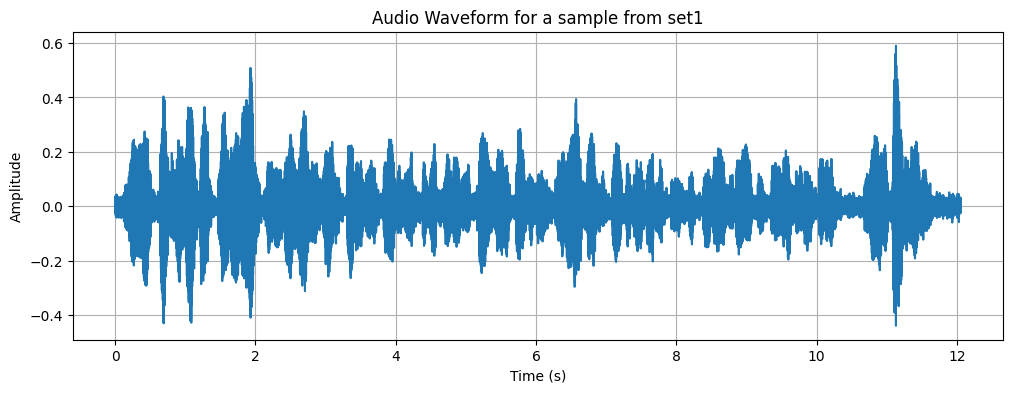

In [11]:
# Plot the waveform
plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(waveform)) / sampling_rate, waveform)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Audio Waveform for a sample from set1")
plt.grid(True)
plt.show()

In [12]:
# Play the audio
print("\nPlaying audio:")
Audio(waveform, rate=sampling_rate)


Playing audio:


**Preprocess Audio**

In [12]:
def load_audio2(audio_source, target_sr=16000):
    if isinstance(audio_source, tuple) and len(audio_source) == 2:
        # If input is (array, sr) from the dataset
        waveform_np, original_sr = audio_source
        # Convert numpy array to tensor, add channel dimension (batch_size, channels, samples)
        # Assuming mono audio in the numpy array, add a channel dimension
        waveform = torch.from_numpy(waveform_np).float().unsqueeze(0)
    else:
        # If input is a file path or other supported torchaudio.load type
        waveform, original_sr = torchaudio.load(audio_source)

    # Convert to mono by averaging channels (if not already mono)
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)

    # Resample if necessary
    if original_sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=original_sr, new_freq=target_sr)
        waveform = resampler(waveform)
    return waveform

# Working on Set 1

**Running Inference**

In [14]:
import json
from jiwer import process_words # Only import process_words
from tqdm import tqdm
import torch
import torchaudio
import numpy as np

references = []
predictions_ctc = []
predictions_rnnt=[]

print("Starting inference and metric collection for set1...")
# Re-initialize set1 to ensure it's not consumed and contains the correct samples
current_set1_iterable = marathi_valid.take(num_rows_per_set)

for sample_idx, sample in tqdm(enumerate(current_set1_iterable)):
    audio_data_decoded = sample["audio_filepath"]
    reference_text = sample["text"]

    language_code="mr"
    try:
        audio_input = load_audio2((audio_data_decoded['array'], audio_data_decoded['sampling_rate'])).to(device)

        with torch.no_grad():
            transcription_ctc = model(audio_input, language_code, "ctc")
            transcription_rnnt = model(audio_input, language_code, "rnnt")

        predicted_text_ctc = transcription_ctc.strip()
        predicted_text_rnnt = transcription_rnnt.strip()

        references.append(reference_text)
        predictions_ctc.append(predicted_text_ctc)
        predictions_rnnt.append(predicted_text_rnnt)
    except RuntimeError as e:
        print(f"Skipping sample {sample_idx} due to audio processing error: {e}. Sample details: {sample}")
        continue

print("Inference for set1 complete. Calculating metrics...")

Starting inference and metric collection for set1...


1184it [1:07:07,  3.40s/it]

Inference for set1 complete. Calculating metrics...


**Calculating WER word-level**

In [15]:
from jiwer import process_words

# For CTC
total_substitutions_ctc = 0
total_deletions_ctc = 0
total_insertions_ctc = 0
total_reference_words_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics = process_words([ref], [pred])
    total_substitutions_ctc += metrics.substitutions
    total_deletions_ctc += metrics.deletions
    total_insertions_ctc += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_ctc += len(ref.split())

# For RNNT
total_substitutions_rnnt = 0
total_deletions_rnnt = 0
total_insertions_rnnt = 0
total_reference_words_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics = process_words([ref], [pred])
    total_substitutions_rnnt += metrics.substitutions
    total_deletions_rnnt += metrics.deletions
    total_insertions_rnnt += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_rnnt += len(ref.split())


print("\n--- CTC Model Results ---")
print(f"Total reference words: {total_reference_words_ctc}")
print(f"Total substitutions: {total_substitutions_ctc}")
print(f"Total deletions: {total_deletions_ctc}")
print(f"Total insertions: {total_insertions_ctc}")

print("\n--- RNNT Model Results ---")
print(f"Total reference words: {total_reference_words_rnnt}")
print(f"Total substitutions: {total_substitutions_rnnt}")
print(f"Total deletions: {total_deletions_rnnt}")
print(f"Total insertions: {total_insertions_rnnt}")


--- CTC Model Results ---
Total reference words: 16768
Total substitutions: 1815
Total deletions: 279
Total insertions: 180

--- RNNT Model Results ---
Total reference words: 16768
Total substitutions: 1686
Total deletions: 301
Total insertions: 169


**Calculating CER character level**

In [16]:
from jiwer import process_characters, cer

# For CTC (Character-level)
total_substitutions_ctc_char = 0
total_deletions_ctc_char = 0
total_insertions_ctc_char = 0
total_reference_chars_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_ctc_char += metrics_char.substitutions
    total_deletions_ctc_char += metrics_char.deletions
    total_insertions_ctc_char += metrics_char.insertions
    total_reference_chars_ctc += len(ref)

# For RNNT (Character-level)
total_substitutions_rnnt_char = 0
total_deletions_rnnt_char = 0
total_insertions_rnnt_char = 0
total_reference_chars_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_rnnt_char += metrics_char.substitutions
    total_deletions_rnnt_char += metrics_char.deletions
    total_insertions_rnnt_char += metrics_char.insertions
    total_reference_chars_rnnt += len(ref)

# Calculate CER for both models
dataset_cer_ctc = cer(references, predictions_ctc)
dataset_cer_rnnt = cer(references, predictions_rnnt)

print("\n--- CTC Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_ctc}")
print(f"Total character substitutions: {total_substitutions_ctc_char}")
print(f"Total character deletions: {total_deletions_ctc_char}")
print(f"Total character insertions: {total_insertions_ctc_char}")
print(f"CER_ctc: {dataset_cer_ctc:.4f}")

print("\n--- RNNT Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_rnnt}")
print(f"Total character substitutions: {total_substitutions_rnnt_char}")
print(f"Total character deletions: {total_deletions_rnnt_char}")
print(f"Total character insertions: {total_insertions_rnnt_char}")
print(f"CER_rnnt: {dataset_cer_rnnt:.4f}")


--- CTC Model Character-level Results ---
Total reference characters: 97135
Total character substitutions: 1360
Total character deletions: 1656
Total character insertions: 1150
CER_ctc: 0.0429

--- RNNT Model Character-level Results ---
Total reference characters: 97135
Total character substitutions: 1464
Total character deletions: 1618
Total character insertions: 1075
CER_rnnt: 0.0428


# Working on Set 2

**Running Inference**

In [13]:
import json
from jiwer import process_words # Only import process_words
from tqdm import tqdm
import torch
import torchaudio
import numpy as np

references = []
predictions_ctc = []
predictions_rnnt=[]

print("Starting inference and metric collection for set2...")
# Re-initialize set2 to ensure it's not consumed and contains the correct samples
current_set2_iterable = marathi_valid.skip(num_rows_per_set).take(num_rows_per_set)

for sample_idx, sample in tqdm(enumerate(current_set2_iterable)):
    audio_data_decoded = sample["audio_filepath"]
    reference_text = sample["text"]

    language_code="mr"
    try:
        audio_input = load_audio2((audio_data_decoded['array'], audio_data_decoded['sampling_rate'])).to(device)

        with torch.no_grad():
            transcription_ctc = model(audio_input, language_code, "ctc")
            transcription_rnnt = model(audio_input, language_code, "rnnt")

        predicted_text_ctc = transcription_ctc.strip()
        predicted_text_rnnt = transcription_rnnt.strip()

        references.append(reference_text)
        predictions_ctc.append(predicted_text_ctc)
        predictions_rnnt.append(predicted_text_rnnt)
    except RuntimeError as e:
        print(f"Skipping sample {sample_idx} due to audio processing error: {e}. Sample details: {sample}")
        continue

print("Inference for set2 complete. Calculating metrics...")

Starting inference and metric collection for set2...


1184it [55:38,  2.82s/it]

Inference for set2 complete. Calculating metrics...


**Calculating WER for Set 2**

In [14]:
from jiwer import process_words

# For CTC
total_substitutions_ctc = 0
total_deletions_ctc = 0
total_insertions_ctc = 0
total_reference_words_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics = process_words([ref], [pred])
    total_substitutions_ctc += metrics.substitutions
    total_deletions_ctc += metrics.deletions
    total_insertions_ctc += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_ctc += len(ref.split())

# For RNNT
total_substitutions_rnnt = 0
total_deletions_rnnt = 0
total_insertions_rnnt = 0
total_reference_words_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics = process_words([ref], [pred])
    total_substitutions_rnnt += metrics.substitutions
    total_deletions_rnnt += metrics.deletions
    total_insertions_rnnt += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_rnnt += len(ref.split())


print("\n--- CTC Model Results ---")
print(f"Total reference words: {total_reference_words_ctc}")
print(f"Total substitutions: {total_substitutions_ctc}")
print(f"Total deletions: {total_deletions_ctc}")
print(f"Total insertions: {total_insertions_ctc}")

print("\n--- RNNT Model Results ---")
print(f"Total reference words: {total_reference_words_rnnt}")
print(f"Total substitutions: {total_substitutions_rnnt}")
print(f"Total deletions: {total_deletions_rnnt}")
print(f"Total insertions: {total_insertions_rnnt}")


--- CTC Model Results ---
Total reference words: 15380
Total substitutions: 1941
Total deletions: 545
Total insertions: 223

--- RNNT Model Results ---
Total reference words: 15380
Total substitutions: 1727
Total deletions: 570
Total insertions: 216


**Calculating CER for Set 2**

In [15]:
from jiwer import process_characters, cer

# For CTC (Character-level)
total_substitutions_ctc_char = 0
total_deletions_ctc_char = 0
total_insertions_ctc_char = 0
total_reference_chars_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_ctc_char += metrics_char.substitutions
    total_deletions_ctc_char += metrics_char.deletions
    total_insertions_ctc_char += metrics_char.insertions
    total_reference_chars_ctc += len(ref)

# For RNNT (Character-level)
total_substitutions_rnnt_char = 0
total_deletions_rnnt_char = 0
total_insertions_rnnt_char = 0
total_reference_chars_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_rnnt_char += metrics_char.substitutions
    total_deletions_rnnt_char += metrics_char.deletions
    total_insertions_rnnt_char += metrics_char.insertions
    total_reference_chars_rnnt += len(ref)

# Calculate CER for both models
dataset_cer_ctc = cer(references, predictions_ctc)
dataset_cer_rnnt = cer(references, predictions_rnnt)

print("\n--- CTC Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_ctc}")
print(f"Total character substitutions: {total_substitutions_ctc_char}")
print(f"Total character deletions: {total_deletions_ctc_char}")
print(f"Total character insertions: {total_insertions_ctc_char}")
print(f"CER_ctc: {dataset_cer_ctc:.4f}")

print("\n--- RNNT Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_rnnt}")
print(f"Total character substitutions: {total_substitutions_rnnt_char}")
print(f"Total character deletions: {total_deletions_rnnt_char}")
print(f"Total character insertions: {total_insertions_rnnt_char}")
print(f"CER_rnnt: {dataset_cer_rnnt:.4f}")


--- CTC Model Character-level Results ---
Total reference characters: 87456
Total character substitutions: 1640
Total character deletions: 3197
Total character insertions: 1317
CER_ctc: 0.0704

--- RNNT Model Character-level Results ---
Total reference characters: 87456
Total character substitutions: 1807
Total character deletions: 3062
Total character insertions: 1231
CER_rnnt: 0.0697


# Working on Set 3

**Running Inference**

In [13]:
import json
from jiwer import process_words # Only import process_words
from tqdm import tqdm
import torch
import torchaudio
import numpy as np

references = []
predictions_ctc = []
predictions_rnnt=[]

print("Starting inference and metric collection for set2...")
# Re-initialize set3 to ensure it's not consumed and contains the correct samples
current_set3_iterable = marathi_valid.skip(2*num_rows_per_set).take(num_rows_per_set)

for sample_idx, sample in tqdm(enumerate(current_set3_iterable)):
    audio_data_decoded = sample["audio_filepath"]
    reference_text = sample["text"]

    language_code="mr"
    try:
        audio_input = load_audio2((audio_data_decoded['array'], audio_data_decoded['sampling_rate'])).to(device)

        with torch.no_grad():
            transcription_ctc = model(audio_input, language_code, "ctc")
            transcription_rnnt = model(audio_input, language_code, "rnnt")

        predicted_text_ctc = transcription_ctc.strip()
        predicted_text_rnnt = transcription_rnnt.strip()

        references.append(reference_text)
        predictions_ctc.append(predicted_text_ctc)
        predictions_rnnt.append(predicted_text_rnnt)
    except RuntimeError as e:
        print(f"Skipping sample {sample_idx} due to audio processing error: {e}. Sample details: {sample}")
        continue

print("Inference for set3 complete. Calculating metrics...")

Starting inference and metric collection for set2...


1184it [58:59,  2.99s/it]

Inference for set3 complete. Calculating metrics...


**Calculating WER for Set3**

In [14]:
from jiwer import process_words

# For CTC
total_substitutions_ctc = 0
total_deletions_ctc = 0
total_insertions_ctc = 0
total_reference_words_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics = process_words([ref], [pred])
    total_substitutions_ctc += metrics.substitutions
    total_deletions_ctc += metrics.deletions
    total_insertions_ctc += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_ctc += len(ref.split())

# For RNNT
total_substitutions_rnnt = 0
total_deletions_rnnt = 0
total_insertions_rnnt = 0
total_reference_words_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics = process_words([ref], [pred])
    total_substitutions_rnnt += metrics.substitutions
    total_deletions_rnnt += metrics.deletions
    total_insertions_rnnt += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_rnnt += len(ref.split())


print("\n--- CTC Model Results ---")
print(f"Total reference words: {total_reference_words_ctc}")
print(f"Total substitutions: {total_substitutions_ctc}")
print(f"Total deletions: {total_deletions_ctc}")
print(f"Total insertions: {total_insertions_ctc}")

print("\n--- RNNT Model Results ---")
print(f"Total reference words: {total_reference_words_rnnt}")
print(f"Total substitutions: {total_substitutions_rnnt}")
print(f"Total deletions: {total_deletions_rnnt}")
print(f"Total insertions: {total_insertions_rnnt}")


--- CTC Model Results ---
Total reference words: 15191
Total substitutions: 2069
Total deletions: 291
Total insertions: 253

--- RNNT Model Results ---
Total reference words: 15191
Total substitutions: 1876
Total deletions: 308
Total insertions: 240


**Calculating CER for set 3**

In [15]:
from jiwer import process_characters, cer

# For CTC (Character-level)
total_substitutions_ctc_char = 0
total_deletions_ctc_char = 0
total_insertions_ctc_char = 0
total_reference_chars_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_ctc_char += metrics_char.substitutions
    total_deletions_ctc_char += metrics_char.deletions
    total_insertions_ctc_char += metrics_char.insertions
    total_reference_chars_ctc += len(ref)

# For RNNT (Character-level)
total_substitutions_rnnt_char = 0
total_deletions_rnnt_char = 0
total_insertions_rnnt_char = 0
total_reference_chars_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_rnnt_char += metrics_char.substitutions
    total_deletions_rnnt_char += metrics_char.deletions
    total_insertions_rnnt_char += metrics_char.insertions
    total_reference_chars_rnnt += len(ref)

# Calculate CER for both models
dataset_cer_ctc = cer(references, predictions_ctc)
dataset_cer_rnnt = cer(references, predictions_rnnt)

print("\n--- CTC Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_ctc}")
print(f"Total character substitutions: {total_substitutions_ctc_char}")
print(f"Total character deletions: {total_deletions_ctc_char}")
print(f"Total character insertions: {total_insertions_ctc_char}")
print(f"CER_ctc: {dataset_cer_ctc:.4f}")

print("\n--- RNNT Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_rnnt}")
print(f"Total character substitutions: {total_substitutions_rnnt_char}")
print(f"Total character deletions: {total_deletions_rnnt_char}")
print(f"Total character insertions: {total_insertions_rnnt_char}")
print(f"CER_rnnt: {dataset_cer_rnnt:.4f}")


--- CTC Model Character-level Results ---
Total reference characters: 85746
Total character substitutions: 1761
Total character deletions: 1847
Total character insertions: 1470
CER_ctc: 0.0592

--- RNNT Model Character-level Results ---
Total reference characters: 85746
Total character substitutions: 1851
Total character deletions: 1713
Total character insertions: 1365
CER_rnnt: 0.0575
